<a href="https://www.kaggle.com/code/lalit7881/phishing-email-eda?scriptVersionId=311957295" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tommyf1/phishing-email-dataset/phishing_dataset (1).xlsx


## Loading dataset

In [2]:
file_path = r"/kaggle/input/datasets/tommyf1/phishing-email-dataset/phishing_dataset (1).xlsx"

df = pd.read_excel(file_path)


In [3]:
df.head()

,id,subject,sender,email_text,has_link,has_attachment,urgency_flag,label
0,1,Monthly Report,admin@company.com,Please find attached the monthly report.,1,0,0,legitimate
1,2,Salary Payment Notification,hr@company.com,Your salary has been credited successfully.,1,1,0,legitimate
2,3,Order Delivered,sales@shop.com,Your order has been delivered. Thank you for s...,0,1,0,legitimate
3,4,Salary Payment Notification,hr@company.com,Your salary has been credited successfully.,0,1,0,legitimate
4,5,Team Meeting Reminder,manager@company.com,Meeting scheduled for tomorrow at 10am.,0,0,0,legitimate


In [4]:
df.tail()

,id,subject,sender,email_text,has_link,has_attachment,urgency_flag,label
795,796,Congratulations Winner!,promo@lottery-ng.com,"You have won 竄ｦ500,000. Click here to claim.",1,1,1,phishing
796,797,BVN Update Required,noreply@fakebank.com,Urgent: Update your BVN immediately to avoid r...,1,1,1,phishing
797,798,BVN Update Required,noreply@fakebank.com,Urgent: Update your BVN immediately to avoid r...,1,1,1,phishing
798,799,Order Delivered,sales@shop.com,Your order has been delivered. Thank you for s...,1,1,0,legitimate
799,800,Monthly Report,admin@company.com,Please find attached the monthly report.,1,1,0,legitimate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              800 non-null    int64 
 1   subject         800 non-null    object
 2   sender          800 non-null    object
 3   email_text      800 non-null    object
 4   has_link        800 non-null    int64 
 5   has_attachment  800 non-null    int64 
 6   urgency_flag    800 non-null    int64 
 7   label           800 non-null    object
dtypes: int64(4), object(4)
memory usage: 50.1+ KB


In [6]:
df.describe()

,id,has_link,has_attachment,urgency_flag
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,0.755000,0.520000,0.517500
std,231.0844,0.430356,0.499912,0.500006
min,1.0000,0.000000,0.000000,0.000000
25%,200.7500,1.000000,0.000000,0.000000
50%,400.5000,1.000000,1.000000,1.000000
75%,600.2500,1.000000,1.000000,1.000000
max,800.0000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

id                0
subject           0
sender            0
email_text        0
has_link          0
has_attachment    0
urgency_flag      0
label             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['id', 'subject', 'sender', 'email_text', 'has_link', 'has_attachment',
       'urgency_flag', 'label'],
      dtype='object')

In [10]:
df.dtypes

id                 int64
subject           object
sender            object
email_text        object
has_link           int64
has_attachment     int64
urgency_flag       int64
label             object
dtype: object

In [11]:
df.shape

(800, 8)

In [12]:
df.nunique()

id                800
subject             8
sender              8
email_text          8
has_link            2
has_attachment      2
urgency_flag        2
label               2
dtype: int64

## EDA

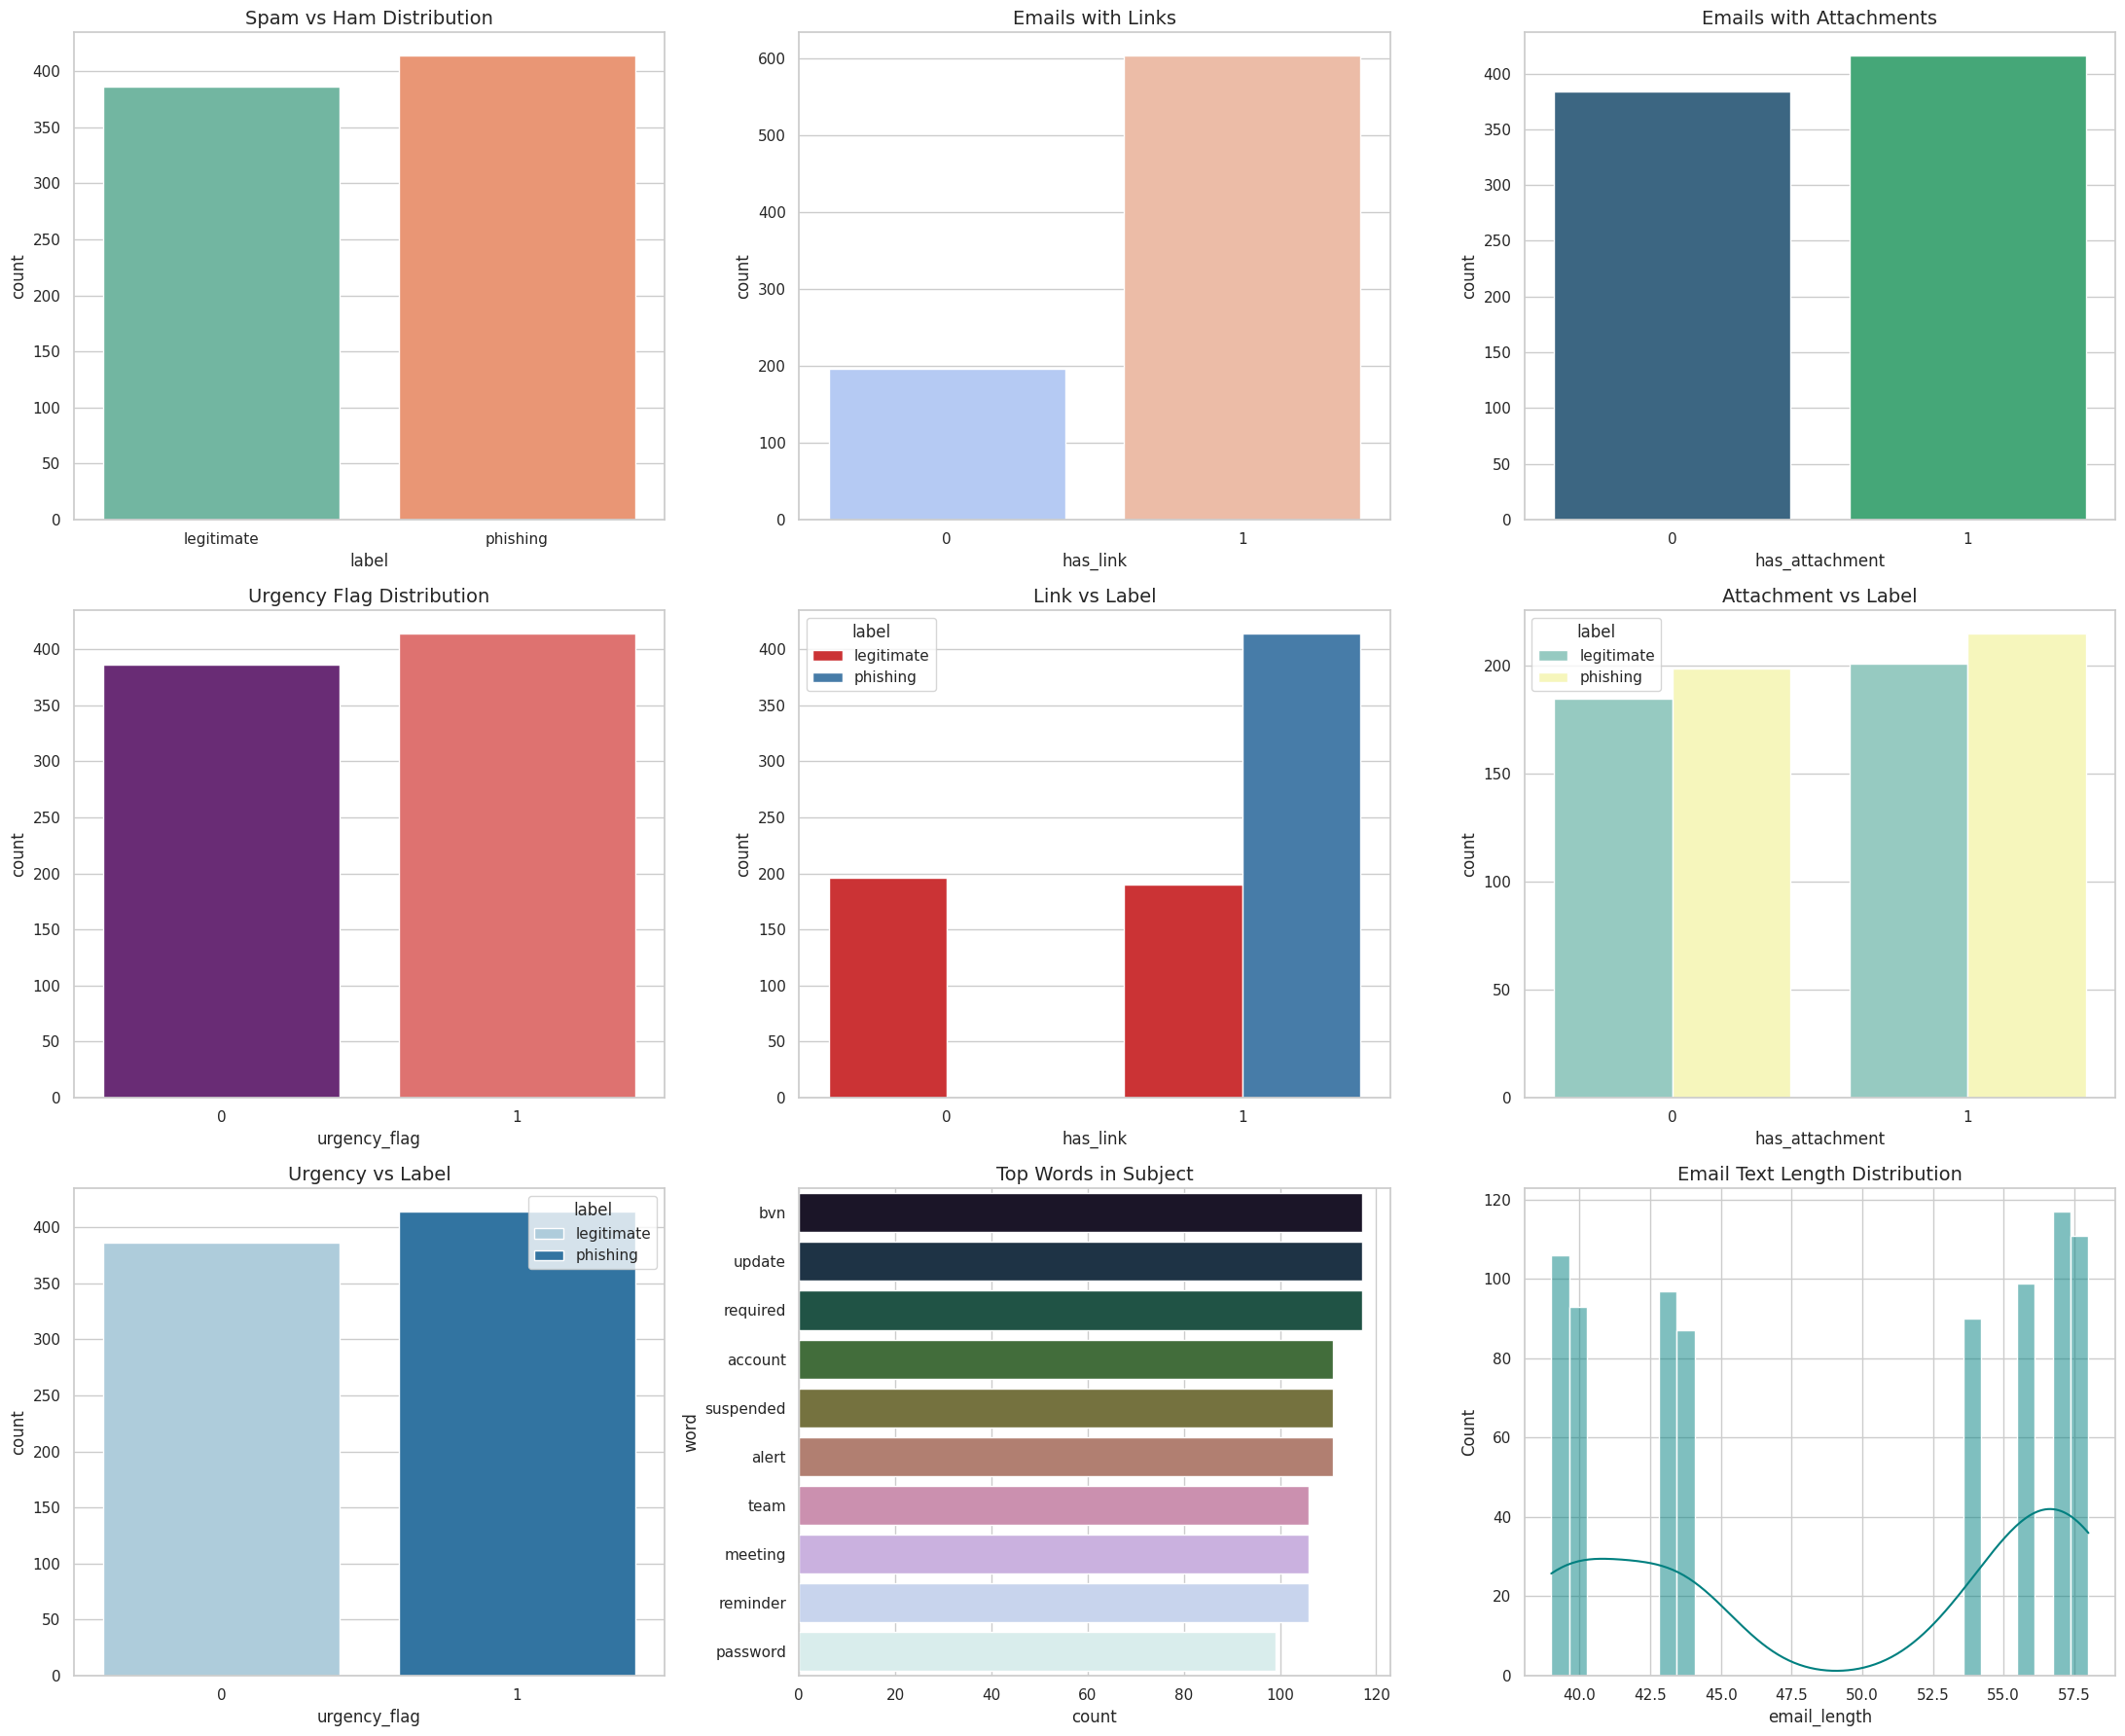

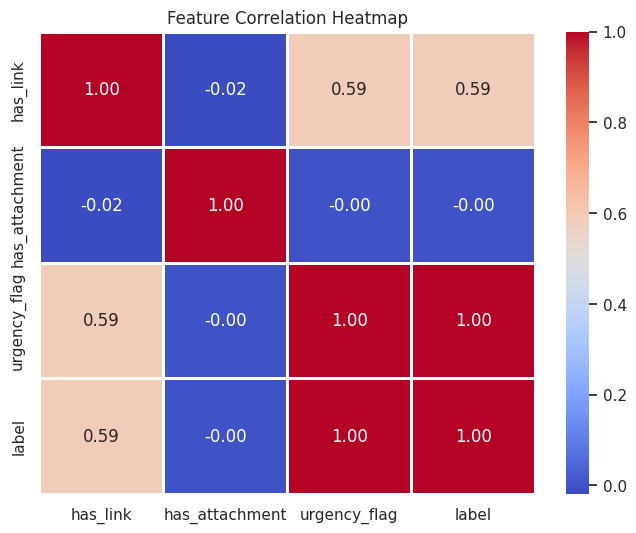

In [13]:
sns.set(style="whitegrid")
plt.figure(figsize=(22, 18))

# =======================
# 1. LABEL DISTRIBUTION
# =======================
plt.subplot(3, 3, 1)
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Spam vs Ham Distribution", fontsize=14)

# =======================
# 2. HAS LINK COUNT
# =======================
plt.subplot(3, 3, 2)
sns.countplot(x='has_link', data=df, palette='coolwarm')
plt.title("Emails with Links", fontsize=14)

# =======================
# 3. HAS ATTACHMENT COUNT
# =======================
plt.subplot(3, 3, 3)
sns.countplot(x='has_attachment', data=df, palette='viridis')
plt.title("Emails with Attachments", fontsize=14)

# =======================
# 4. URGENCY FLAG
# =======================
plt.subplot(3, 3, 4)
sns.countplot(x='urgency_flag', data=df, palette='magma')
plt.title("Urgency Flag Distribution", fontsize=14)

# =======================
# 5. LABEL vs LINK
# =======================
plt.subplot(3, 3, 5)
sns.countplot(x='has_link', hue='label', data=df, palette='Set1')
plt.title("Link vs Label", fontsize=14)

# =======================
# 6. LABEL vs ATTACHMENT
# =======================
plt.subplot(3, 3, 6)
sns.countplot(x='has_attachment', hue='label', data=df, palette='Set3')
plt.title("Attachment vs Label", fontsize=14)

# =======================
# 7. LABEL vs URGENCY
# =======================
plt.subplot(3, 3, 7)
sns.countplot(x='urgency_flag', hue='label', data=df, palette='Paired')
plt.title("Urgency vs Label", fontsize=14)

# =======================
# 8. TOP SUBJECT WORDS
# =======================
from collections import Counter
import re

all_subjects = " ".join(df['subject'].dropna().astype(str)).lower()
words = re.findall(r'\b\w+\b', all_subjects)

common_words = Counter(words).most_common(10)
words_df = pd.DataFrame(common_words, columns=['word', 'count'])

plt.subplot(3, 3, 8)
sns.barplot(x='count', y='word', data=words_df, palette='cubehelix')
plt.title("Top Words in Subject", fontsize=14)

# =======================
# 9. EMAIL LENGTH ANALYSIS
# =======================
df['email_length'] = df['email_text'].astype(str).apply(len)

plt.subplot(3, 3, 9)
sns.histplot(df['email_length'], bins=30, kde=True, color='teal')
plt.title("Email Text Length Distribution", fontsize=14)

# =======================
# FINAL LAYOUT
# =======================
plt.tight_layout()
plt.show()

# =======================
# EXTRA: CORRELATION HEATMAP (FIXED)
# =======================

from sklearn.preprocessing import LabelEncoder

# Use copy to avoid modifying original data
df_copy = df.copy()

# Encode label if needed
if df_copy['label'].dtype == 'object':
    le = LabelEncoder()
    df_copy['label'] = le.fit_transform(df_copy['label'])

# Ensure numeric columns are numeric
for col in ['has_link', 'has_attachment', 'urgency_flag']:
    df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')

# Plot heatmap
plt.figure(figsize=(8,6))

numeric_cols = ['has_link', 'has_attachment', 'urgency_flag', 'label']

sns.heatmap(
    df_copy[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        77
           1       1.00      1.00      1.00        83

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


Naive Bayes
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        77
           1       1.00      1.00      1.00        83

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


Random Forest
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        77
           1       1.00      1.00      1.00        83

    accuracy    

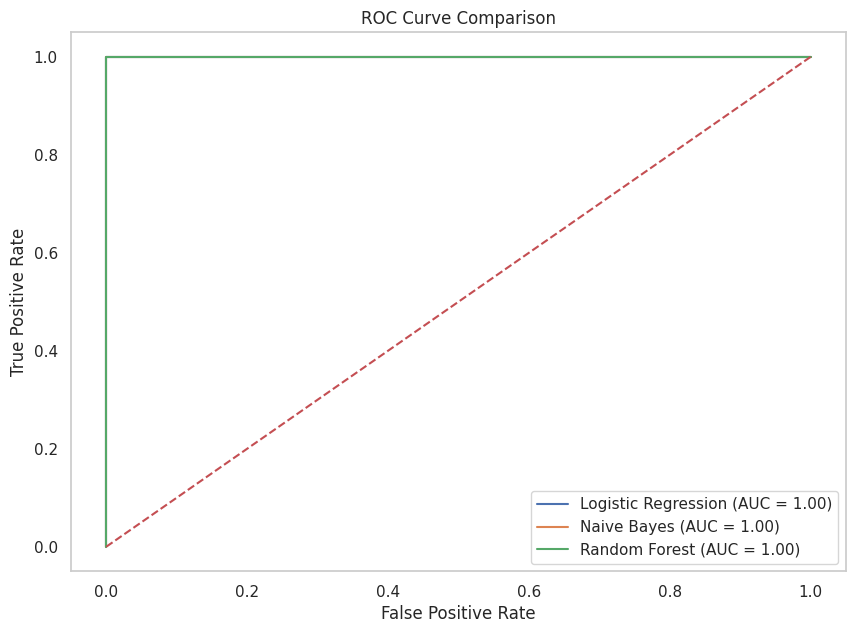

In [14]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc



# ==============================
# BASIC CLEANING
# ==============================
df = df.dropna(subset=['email_text', 'label'])

# ==============================
# TARGET (LABEL)
# ==============================
le_label = LabelEncoder()
df['label'] = le_label.fit_transform(df['label'])   # safe for target

# ==============================
# FEATURE ENGINEERING
# ==============================
# Convert categorical columns AFTER split (to avoid leakage)

# Text feature
X_text = df['email_text']

# Other features
X_other = df[['has_link', 'has_attachment', 'urgency_flag']]

y = df['label']

# ==============================
# TRAIN TEST SPLIT (IMPORTANT)
# ==============================
X_text_train, X_text_test, X_other_train, X_other_test, y_train, y_test = train_test_split(
    X_text, X_other, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# TF-IDF (ONLY FIT ON TRAIN)
# ==============================
tfidf = TfidfVectorizer(max_features=5000)

X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

# ==============================
# COMBINE FEATURES
# ==============================
from scipy.sparse import hstack

X_train = hstack([X_text_train_tfidf, X_other_train])
X_test = hstack([X_text_test_tfidf, X_other_test])

# ==============================
# MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ==============================
# TRAIN + EVALUATE
# ==============================
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print("="*40)
    print("Accuracy:", acc)

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ==============================
# ROC PLOT
# ==============================
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

## Thank you...pls upvote!!!!!!!